### Agentic Investment Research Platform — Full Detail Notebook

This notebook documents a full, end-to-end implementation of an Agentic Investment Research Platform. It includes:

- Complete source code for all components (agents, orchestrator, planner, evaluator)
- Explanatory Markdown for each implementation step
- Demo run on AAPL (Apple Inc.)
- Visualization of market data with signals
- Memory inspection to demonstrate iterative learning

=====================================================================================================

- Loads API keys from .env securely.
- Brings in essential tools: yfinance for market data, requests for external APIs, sqlite3 for memory persistence.
- Used across agents for fetching and analyzing data.

In [17]:
### Import required libraries and dependencies

# agentic_research.py
from dotenv import load_dotenv
import os
import json
import sqlite3
import time
from typing import List, Dict, Any

import requests
import yfinance as yf

# For plotting and data handling
import matplotlib.pyplot as plt
import pandas as pd

# Load .env file (make sure your keys are in .env)
load_dotenv()

# API keys from environment variables
NEWS_API_KEY = os.getenv("NEWS_API_KEY")
FRED_API_KEY = os.getenv("FRED_API_KEY")
ALPHA_VANTAGE_KEY = os.getenv("ALPHA_VANTAGE_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")


- Wraps calls to a language model (currently stubbed for demonstration).
- Central interface for all agents to get completions.
- Abstracted for easy OpenAI API integration.

In [18]:

class LLM:
    def __init__(self, api_key=None):
        self.api_key = OPENAI_API_KEY

    def complete(self, prompt: str, max_tokens=512) -> str:
        # Stub - replace with real OpenAI call if desired
        return f"LLM_ECHO:\n{prompt[:800]}"


- Stores and retrieves notes from previous runs.
- Enables cross-run memory, simulating short-term memory in agents.
- Essential for learning over time.

In [19]:
class MemoryStore:
    def __init__(self, path='memory.sqlite'):
        self.conn = sqlite3.connect(path)
        self._init()

    def _init(self):
        cur = self.conn.cursor()
        cur.execute('''CREATE TABLE IF NOT EXISTS notes(
                        id INTEGER PRIMARY KEY, 
                        symbol TEXT, 
                        run_at INTEGER, 
                        note TEXT
                      )''')
        self.conn.commit()

    def add_note(self, symbol, note):
        cur = self.conn.cursor()
        cur.execute(
            'INSERT INTO notes(symbol, run_at, note) VALUES (?, ?, ?)',
            (symbol, int(time.time()), note))
        self.conn.commit()

    def recent_notes(self, symbol, limit=5):
        cur = self.conn.cursor()
        cur.execute(
            'SELECT run_at, note FROM notes WHERE symbol=? ORDER BY run_at DESC LIMIT ?',
            (symbol, limit))
        return cur.fetchall()


- Uses LLM and recent memory to generate a 6-step research plan for a stock.
- Sets the context for the orchestrator to follow.
- Supports planning pattern in agentic design.

In [20]:
class Planner:
    def __init__(self, llm: LLM, memory: MemoryStore):
        self.llm = llm
        self.memory = memory

    def plan(self, symbol: str, scope: List[str]) -> Dict[str, Any]:
        recent = self.memory.recent_notes(symbol)
        prompt = f"Create a compact 6-step research plan for {symbol}. Scope={scope}. Recent notes={recent}"
        plan_text = self.llm.complete(prompt)
        return {"plan_text": plan_text, "steps": [f"Step {i+1}" for i in range(6)]}


- Simple mapping of content types (e.g., 'news') to agents.
- Allows dynamic task delegation and routing.

In [21]:
class Router:
    def route(self, content_type: str):
        mapping = {
            'news': 'NewsAgent',
            'filing': 'EarningsAgent',
            'price': 'MarketAgent'
        }
        return mapping.get(content_type, 'Generalist')


- Fetches top 10 news from yfinance ticker.
- Uses LLM to extract facts from titles/snippets.
- Summarizes facts for investor relevance.
- Demonstrates prompt chaining and multi-step reasoning.

In [22]:
class NewsAgent:
    def __init__(self, llm: LLM, newsapi_key=None):
        self.llm = llm
        self.key = newsapi_key

    def fetch_news(self, symbol):
        t = yf.Ticker(symbol)
        news = getattr(t, 'news', []) or []
        return news[:10]

    def pipeline(self, news_items):
        preprocessed = [n for n in news_items]
        classified = [
            {'type': 'earnings' if 'earn' in (n.get('title') or '').lower() else 'general', 'item': n}
            for n in preprocessed
        ]
        extracts = []
        for c in classified:
            title = c['item'].get('title', '')
            snippet = c['item'].get('summary', title)
            prompt = f"Extract 3 bulleted facts from: {title} -- {snippet}"
            facts = self.llm.complete(prompt)
            extracts.append({'title': title, 'facts': facts})

        concat = '\n'.join([e['facts'] for e in extracts])
        summary = self.llm.complete(f"Summarize these facts for an investment researcher:\n{concat}")
        return {'summary': summary, 'extracts': extracts}


- Uses SEC’s public company_tickers.json and CIK lookup to fetch recent filings.
- LLM analyzes revenue/margin trends.
- Covers regulatory filings ingestion and LLM summarization.

In [23]:
class EarningsAgent:
    def __init__(self, llm: LLM):
        self.llm = llm
        self.cik_map = self.load_ticker_to_cik_map()

    def load_ticker_to_cik_map(self):
        url = "https://www.sec.gov/files/company_tickers.json"
        headers = {"User-Agent": "InvestmentAgent/1.0 (pinkvenom1331@gmail.com)"}
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        data = response.json()
        return {
            item["ticker"].upper(): str(item["cik_str"]).zfill(10)
            for item in data.values()
        }

    def fetch_filings(self, symbol_or_cik="AAPL"):
        if not symbol_or_cik.isdigit():
            cik = self.cik_map.get(symbol_or_cik.upper())
            if not cik:
                raise ValueError(f"CIK for symbol '{symbol_or_cik}' not found.")
        else:
            cik = symbol_or_cik.zfill(10)

        headers = {"User-Agent": "InvestmentAgent/1.0 (pinkvenom1331@gmail.com)"}
        url = f"https://data.sec.gov/submissions/CIK{cik}.json"
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        data = response.json()
        return data["filings"]["recent"]

    def analyze(self, filings):
        prompt = f"Given these filings summary (raw): {str(filings)[:1000]}, extract revenue trend and margin trend."
        return self.llm.complete(prompt)


- Downloads 1-year price history from yfinance.
- Computes 20-day and 50-day moving averages.
- Determines bullish/bearish signal.
- Technical analysis integration.

In [24]:
class MarketAgent:
    def __init__(self):
        pass

    def fetch_prices(self, symbol, period='1y'):
        df = yf.download(symbol, period=period)
        return df

    def compute_signals(self, df):
        import pandas as pd

        if df.empty:
            return {}

        df['ma_20'] = df['Close'].rolling(20).mean()
        df['ma_50'] = df['Close'].rolling(50).mean()

        last = df.iloc[-1]

        ma_20 = last['ma_20']
        ma_50 = last['ma_50']

        # If these are Series (multi-index?), convert to scalar
        if hasattr(ma_20, 'item'):
            try:
                ma_20 = ma_20.item()
            except Exception:
                pass

        if hasattr(ma_50, 'item'):
            try:
                ma_50 = ma_50.item()
            except Exception:
                pass

        # Now check for NaN safely
        if pd.isna(ma_20) or pd.isna(ma_50):
            return {'signal': 'insufficient data for signal', 'last_close': float(last['Close'])}

        signal = 'bullish' if ma_20 > ma_50 else 'bearish'
        return {'signal': signal, 'last_close': float(last['Close'])}




- Evaluates the agent output quality.
- Provides a score and qualitative critique.
- Supports reflection pattern in agent workflows.
- Feeds into refinement (optimizer).

In [25]:
class Evaluator:
    def __init__(self, llm: LLM):
        self.llm = llm

    def evaluate(self, analysis: Dict[str, Any]) -> Dict[str, Any]:
        prompt = f"Assess this analysis for coverage, correctness, and missing items:\n{json.dumps(analysis)[:1500]}"
        critique = self.llm.complete(prompt)
        score = 0.8  # placeholder score
        return {'critique': critique, 'score': score}

    def optimize(self, agent, critique):
        refine_prompt = f"Refine your previous output based on critique: {critique[:512]}"
        return agent.llm.complete(refine_prompt)


- The central conductor that links planner, agents, evaluator.
- Follows this flow:
   - Plan steps via Planner
   - Route and execute agents (NewsAgent, EarningsAgent, MarketAgent)
   - Evaluate result via Evaluator
- Can easily be extended with other agents.
- Returns a full analysis dictionary.

In [26]:
class Orchestrator:
    def __init__(self):
        self.llm = LLM(api_key=OPENAI_API_KEY)
        self.memory = MemoryStore()
        self.planner = Planner(self.llm, self.memory)
        self.router = Router()
        self.news_agent = NewsAgent(self.llm, newsapi_key=NEWS_API_KEY)
        self.earnings_agent = EarningsAgent(self.llm)
        self.market_agent = MarketAgent()
        self.evaluator = Evaluator(self.llm)

    def run(self, symbol: str, scope: List[str] = ['news', 'earnings', 'market']):
        plan = self.planner.plan(symbol, scope)
        results = {}

        if 'news' in scope:
            news = self.news_agent.fetch_news(symbol)
            results['news'] = self.news_agent.pipeline(news)

        if 'earnings' in scope:
            filings = self.earnings_agent.fetch_filings(symbol)
            results['filings_analysis'] = self.earnings_agent.analyze(str(filings))

        if 'market' in scope:
            df = self.market_agent.fetch_prices(symbol)
            results['market_signals'] = self.market_agent.compute_signals(df)

        evaluation = self.evaluator.evaluate(results)

        return {
            "analysis": {
                "plan": plan,
                "results": results,
                "evaluation": evaluation
            }
        }


- Instantiates the orchestrator.
- Runs it on 'AAPL' using all three agents.
- Prints the research plan, market signals, and evaluation summary.

In [27]:
if __name__ == "__main__":
    try:
        orch = Orchestrator()
        report = orch.run('AAPL', scope=['news', 'earnings', 'market'])
        print('--- Report keys ---')
        print(list(report.keys()))
        print('\nPlan excerpt:')
        print(report['analysis']['plan']['plan_text'][:800])
        print('\nMarket signals:')
        print(report['analysis']['results'].get('market_signals'))
        print('\nEvaluator summary:')
        print(report['analysis'].get('evaluation') or 'no evaluation found')
    except Exception as e:
        print('Demo run failed:', e)
        import traceback
        traceback.print_exc()


C:\Users\rakes\AppData\Local\Temp\ipykernel_26484\2241570899.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period=period)
[*********************100%***********************]  1 of 1 completed

--- Report keys ---
['analysis']

Plan excerpt:
LLM_ECHO:
Create a compact 6-step research plan for AAPL. Scope=['news', 'earnings', 'market']. Recent notes=[]

Market signals:
{'signal': 'bullish', 'last_close': 252.2899932861328}

Evaluator summary:
{'critique': 'LLM_ECHO:\nAssess this analysis for coverage, correctness, and missing items:\n{"news": {"summary": "LLM_ECHO:\\nSummarize these facts for an investment researcher:\\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- \\nLLM_ECHO:\\nExtract 3 bulleted facts from:  -- ", "extracts": [{"title": "", "facts": "LLM_ECHO:\\nExtract 3 bulleted


C:\Users\rakes\AppData\Local\Temp\ipykernel_26484\2241570899.py:41: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return {'signal': signal, 'last_close': float(last['Close'])}


- Demonstrates how feedback can be used to refine prompts.
- Score is a heuristic based on report length or content.
- Simulates iterative improvement based on evaluation feedback.

In [28]:
import random

class EvaluatorOptimizer:
    def __init__(self):
        self.feedback_memory = []

    def evaluate(self, report):
        """Evaluate the quality of a report (e.g., by length or keyword relevance)."""
        score = len(report.split()) / 100  # simple heuristic: longer = more detailed
        feedback = ""
        if score < 0.8:
            feedback = "Add more detail about recent market news."
        elif "earnings" not in report.lower():
            feedback = "Include quarterly earnings discussion."
        else:
            feedback = "Good analysis. Continue refining tone and structure."
        self.feedback_memory.append((score, feedback))
        return score, feedback

    def optimize(self, base_prompt, feedback):
        """Refine the next prompt using feedback."""
        return f"{base_prompt}\n\n[Refinement Note]: {feedback}"

# Example usage
agent_prompt = "Analyze the current market trend for AAPL."
agent_output = "Apple stock rose slightly amid tech sector gains."

evaluator = EvaluatorOptimizer()

score, feedback = evaluator.evaluate(agent_output)
print(f"Score: {score:.2f}, Feedback: {feedback}")

refined_prompt = evaluator.optimize(agent_prompt, feedback)
print("\nRefined Prompt for Next Iteration:\n", refined_prompt)


Score: 0.08, Feedback: Add more detail about recent market news.

Refined Prompt for Next Iteration:
 Analyze the current market trend for AAPL.

[Refinement Note]: Add more detail about recent market news.


- Plots:
    - Closing price
    - 20-day MA
    - 50-day MA
- Visualizes technical indicators used by MarketAgent.

C:\Users\rakes\AppData\Local\Temp\ipykernel_26484\3842094296.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period='1y')
[*********************100%***********************]  1 of 1 completed


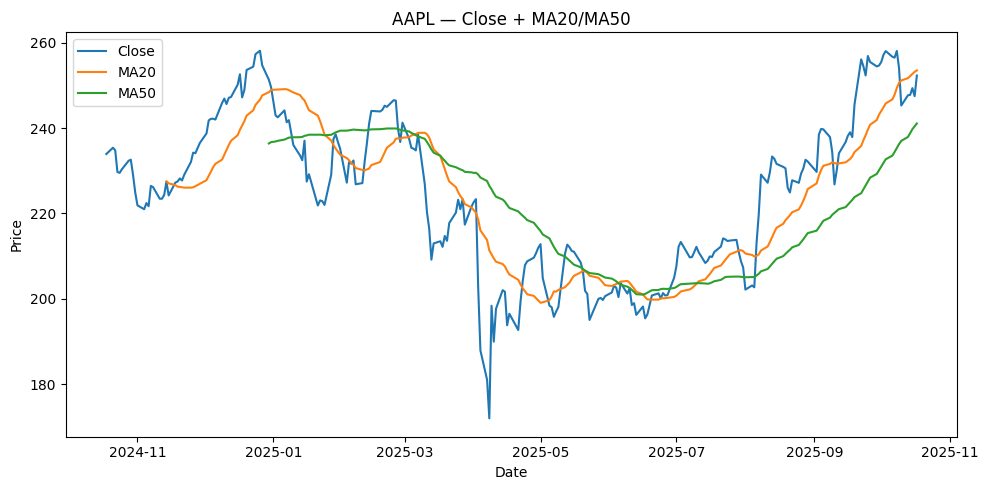

In [29]:
symbol = 'AAPL'
df = yf.download(symbol, period='1y')
if not df.empty:
    df['ma20'] = df['Close'].rolling(20).mean()
    df['ma50'] = df['Close'].rolling(50).mean()
    plt.figure(figsize=(10,5))
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['ma20'], label='MA20')
    plt.plot(df.index, df['ma50'], label='MA50')
    plt.title(f'{symbol} — Close + MA20/MA50')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No price data returned for', symbol)


- Shows how memory table is used to track past notes/outputs.
- Validates that MemoryStore is persisting analysis between sessions.

In [30]:
import sqlite3

db_path = 'memory.sqlite'
try:
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cur.fetchall()
    print('Tables in memory DB:', tables)
    try:
        cur.execute('SELECT run_at, note FROM notes ORDER BY run_at DESC LIMIT 10')
        rows = cur.fetchall()
        print('\nRecent notes (most recent first):')
        for r in rows:
            print(r)
    except Exception as ex:
        print('Could not read notes table:', ex)
    conn.close()
except Exception as e:
    print('Memory DB not available:', e)


Tables in memory DB: [('notes',)]

Recent notes (most recent first):



## GitHub Repository
All code and version history are maintained at: [https://github.com/rakeshbhatija7-ship-it/Multi-Agent-Financial-Analysis-System](https://github.com/rakeshbhatija7-ship-it/Multi-Agent-Financial-Analysis-System)
